# Strain to phase Relationship

The strain induced by a graviational wave is $h$. This corresponds to a change in arm length of 
$hL = \delta L$.

The arm length of earth based interferometers can only be of the order of kilometers. By using a Fabret-Perot cavity, the number of bounces from the end test mass can be changed by a statistical factor $B$.

The phase shift that the light experiences due to interacting with the gravitational wave detector is 

$\Delta \phi = \frac{4\pi LB}{\lambda_{EM}}h $.

Numerically, this is:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

pi = 3.14159265
L = 1e3 #length of arm
B = 250 #bounces due to FP cavity to optimise for the GW signal
lambda_EM = 1064e-9 #wavelength of light
h = 1e-23 # gravitational wave strain
delta_phi = 4*pi*L*B*h/lambda_EM

print('delta phi required: {0:1E}'.format(delta_phi))

delta phi required: 2.952625E-11


# Energetic Quantum Limit
If you measure a time, then there is an associated uncertainty in that measurement relating to the energy in the system used to measure that time. If the period of an oscllator is used to measure the time then  the energy of the oscillator determines how precisely the time can be known by the HUP

$\Delta E \Delta T \geq \hbar/2$.

The uncertainty in time is related to the uncertainty in phase by 

$\Delta \phi = \omega_{EM} \Delta T$.

As the laser is in a coherent state, the uncertainty in the number of photons detected in time $T$ is $\Delta N = \sqrt{N}$

The energy used to measure this time is determined by half of a the graviational waves period (if the zero crossings of the EM wave are being used). This time $T$ corresponds to $1/2f$, where $f$ is the frequency of the gravitational wave. The power of the laser is $I_0 = \hbar\omega_{EM}N$, where N is the number of photons detected in the time interval $T$, and so the energy used to measure the time is

$E = I_0 T = I_0 \frac{1}{2f} = \hbar\omega_{EM}N$.

and so 

$\Delta E = \hbar\omega_{EM}\Delta N$.

The HUP can now be written as

$ \frac{\Delta \phi}{\omega_{EM}} \hbar\omega_{EM}\Delta N \geq \hbar/2$

which reduces to 

$ \Delta \phi \geq \frac{1}{2\sqrt{N}} $.

or

$ N \geq \frac{1}{4 (\Delta \phi)^2} $

This gives the number of photons required to measure a certain amount of phase. 

For an SNR of 10, this is: 

In [3]:
SNR = 10
N_photon = 1/(4*(delta_phi/SNR)**2)

c = 3e8
hbar = 1e-34
omega_EM = c*2*pi/lambda_EM
grav_wave_f = 100

laser_power = hbar*omega_EM*N_photon*2*grav_wave_f

print('''Number of photons required: {0:1E} 
Power required: {1:1E}'''.format(N_photon,laser_power))

Number of photons required: 2.867633E+22 
Power required: 1.016045E+06


# Power Recyling

The power made by the laser is 100W. We need 1MW. Therefore, the power needs to be increased by a factor of $G = 10000$. To do this, introduce a power recycling cavity. This is explained here: https://doi.org/10.1016/S0375-9601(96)00893-6

The required PRM parameters are:

$G = \frac{\tau_{PRM}^2}{(1-r_{PRM}r_{MI})^2}$

The reflectivity of the PRM that is opimtal corresponds to the losses in the michelson interferometer $\Gamma = 1- r_{MI}$.

The combination of $G$ and $\Gamma$ gives the required PRM transmission. $\Gamma$ arises due to contrast defect.

# Shot noise plot
could be wrong

In [4]:
G = 4*pi*L* B/lambda_EM

bandwidth_of_measurement = grav_wave_f;

noise = np.sqrt(hbar*omega_EM* bandwidth_of_measurement/(2*laser_power)) * 1/G 

#shot_noise_ASD = np.sqrt(hbar*omega_EM/(2*laser_power)) / G

#shot_noise_ASD_1 = np.sqrt(hbar*omega_EM/(2*laser_power))/G2
#shot_noise_ASD_2 = np.sqrt(hbar*omega_EM/(2*laser_power*G2**2))

#shot_noise_ASD_3 = np.sqrt(hbar*omega_EM/2*laser_power)*1/TF

#print('shot noise = {0:3E} h/sqrt(Hz)'.format(shot_noise_ASD))
#print('DC gain = {0:3E} '.format(DC_gain))
#print('Rough DC gain = {0:3E}'.format(rough_DC_gain))
#print('finesse = {0:3E}'.format(finesse))
print('rms shot noise: {0:E}'.format(noise))

rms shot noise: 1.000000E-24


# Fabry Perot Cavity Reflected Light

C:\anaconda3\lib\site-packages\numpy\core\_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


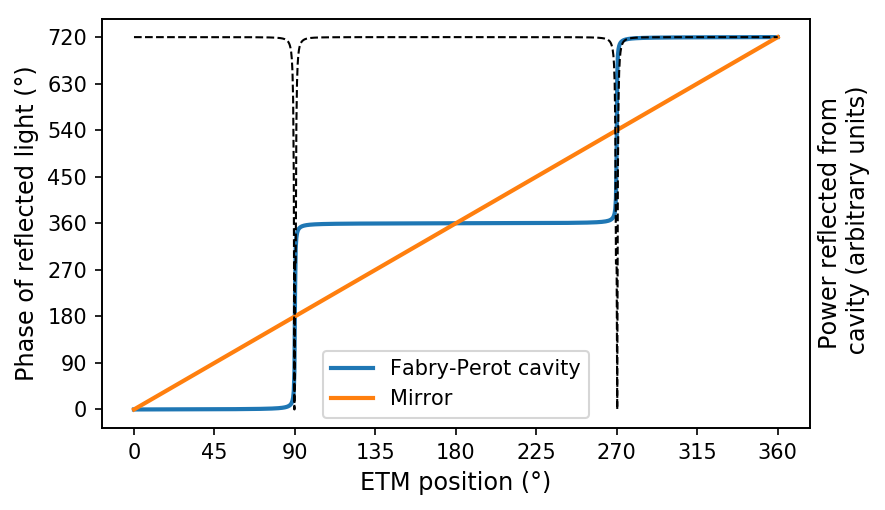

In [17]:
T1 = 0.014
R1 = 1 - T1
detuning = np.linspace(0,2*np.pi,1000)
k = 2*pi*lambda_EM

t1 = np.sqrt(T1)
r1 =np.sqrt(R1)
r2 = np.sqrt(1-100e-6)


a_4 = r1 - r2*t1**2*np.exp(-1j*(-2*detuning-np.pi))/(1 - r1*r2*np.exp(-1j*(-2*detuning-np.pi)))
no_cav_phase = 2*detuning 

figure_size = (6,3.5)
plt.figure(figsize = figure_size,dpi = 150)
plt.plot(detuning*180/np.pi,np.unwrap(np.angle(a_4) )*180/np.pi, label = 'Fabry-Perot cavity',linewidth = 2)
plt.plot(detuning*180/np.pi, no_cav_phase*180/np.pi, label = 'Mirror',linewidth = 2)
#plt.plot(detuning*180/np.pi,720*a_4**2)
plt.xlabel('ETM position (°)', fontsize = 11.5)
plt.ylabel('Phase of reflected light (°)', fontsize = 11.5)
plt.xticks(np.arange(0,361,45))
plt.yticks(np.arange(0,721,90))
plt.legend(loc = 'lower center')
ax2 = plt.gca().twinx()
ax2.plot(detuning*180/np.pi, a_4**2,linewidth = 1,linestyle ='--',color = 'black')
#ax2.spines['right'].set_color('tab:red')
#ax2.yaxis.label.set_color('tab:red')
plt.yticks([])
plt.ylabel('Power reflected from\n cavity (arbitrary units)',fontsize = 11.5)
plt.tight_layout()
plt.savefig('detector_chapter_fabry_vs_mirror.eps')
plt.show()

#figure_size = (6,1)
#plt.figure(figsize = figure_size,dpi = 150)
#plt.plot(detuning*180/np.pi, a_4**2,linewidth = 1,color = 'tab:blue',)
#plt.xlabel('ETM position (°)', fontsize = 11.5)
#plt.ylabel('Power (A.U.)', fontsize = 11.5)
#plt.xticks(np.arange(0,361,45))
#plt.yticks([])
#plt.ylabel('Power reflected from cavity (arbitary units)')
#plt.tight_layout()
#plt.savefig('detector_chapter_fabry_vs_mirror_power.eps')
#plt.show()